# Autoencoder vs Baseline — Comparison

Comparación cuantitativa y visual del **Level 1 autoencoder** (ae-v1) contra el
**baseline PCA→UMAP→kNN** (poster-v2).

Dimensiones de comparación:
1. **Trustworthiness** — ¿el AE preserva mejor los vecindarios locales?
2. **Estabilidad kNN** — ¿el grafo sobre bottleneck es más estable entre seeds?
3. **UMAP scatter lado a lado** — ¿se revelan nuevos clusters?
4. **Distribución de distancias** — ¿las distancias kNN son más informativas?
5. **Tabla resumen** — comparación compacta para el paper

In [1]:
import json, sys, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import trustworthiness
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)

ROOT = Path("/shared/Code/OXOR")
BASELINE_TAG = "poster-v2"
AE_TAG = "ae-v1"
DATASETS = ["global_snp", "global_silico", "lowdensity_snp", "lowdensity_silico"]
SEEDS = [42, 52, 62]
FIG_DIR = ROOT / "docs" / "figures" / "comparison"
FIG_DIR.mkdir(parents=True, exist_ok=True)
DPI = 300

sys.path.insert(0, str(ROOT / "scripts"))
from load_dart import load_genotypes, filter_missingness
from sklearn.impute import SimpleImputer

def load_nodes(tag, ds, seed):
    if tag == AE_TAG:
        p = ROOT / "experiments" / ds / tag / f"seed{seed}" / "ae_embedding_nodes.json"
    else:
        p = ROOT / "experiments" / ds / tag / f"seed{seed}_{ds}_nodes.json"
    with open(p) as f:
        return json.load(f)

def load_edges(tag, ds, seed):
    if tag == AE_TAG:
        p = ROOT / "experiments" / ds / tag / f"seed{seed}" / "ae_embedding_edges.json"
    else:
        p = ROOT / "experiments" / ds / tag / f"seed{seed}_{ds}_edges.json"
    with open(p) as f:
        return json.load(f)

def load_validation(ds):
    p = ROOT / "experiments" / ds / BASELINE_TAG / f"all_{ds}_validation.json"
    with open(p) as f:
        return json.load(f)

DS_INPUTS = {
    "global_snp": "data/10.21223P30BVZYY_Genetic_diversity/SNP_Genotypes.csv",
    "global_silico": "data/10.21223P30BVZYY_Genetic_diversity/SilicoDArT_Genotypes.csv",
    "lowdensity_snp": "data/10.21223P3UBDJ44_LowDensity/01_Report_DSp25-515_SNPs_Filtered_by _reads.csv",
    "lowdensity_silico": "data/10.21223P3UBDJ44_LowDensity/02_Report_DSp25-515_Silico-DArT_Filtered_by_reads.csv",
}

ds_labels = {
    "global_snp": "Global SNP",
    "global_silico": "Global SilicoDArT",
    "lowdensity_snp": "LowDensity SNP",
    "lowdensity_silico": "LowDensity SilicoDArT",
}

print("✓ Setup ready")

✓ Setup ready


## 1. Trustworthiness — AE bottleneck vs PCA embedding

Comparamos `trustworthiness(X_original, X_reduced, k=15)` donde:
- **Baseline**: `X_reduced` = UMAP 2D (del baseline PCA→UMAP)
- **AE bottleneck**: `X_reduced` = bottleneck 64D del autoencoder
- **AE UMAP**: `X_reduced` = UMAP 2D aplicado al bottleneck

In [2]:
trust_results = []

for ds in DATASETS:
    print(f"\n--- {ds_labels[ds]} ---")
    X_raw, sample_ids, sample_meta = load_genotypes(ROOT / DS_INPUTS[ds])
    X_raw, _ = filter_missingness(X_raw, sample_thresh=0.50, marker_thresh=0.50)
    imp = SimpleImputer(strategy="most_frequent")
    X_high = imp.fit_transform(X_raw)
    sample_ids = list(X_raw.index.astype(str))
    print(f"  X_high shape: {X_high.shape}")
    
    k = 15
    
    for seed in SEEDS:
        # Baseline: trust on UMAP 2D
        b_nodes = load_nodes(BASELINE_TAG, ds, seed)
        b_emb = np.array([n["embedding"] for n in b_nodes])
        trust_baseline = trustworthiness(X_high, b_emb, n_neighbors=min(k, len(b_nodes)-1))
        
        # AE: trust on bottleneck 64D and on UMAP 2D
        ae_nodes = load_nodes(AE_TAG, ds, seed)
        ae_bn = np.array([n["bottleneck"] for n in ae_nodes])
        ae_2d = np.array([n["embedding"] for n in ae_nodes])
        trust_ae_bn = trustworthiness(X_high, ae_bn, n_neighbors=min(k, len(ae_nodes)-1))
        trust_ae_2d = trustworthiness(X_high, ae_2d, n_neighbors=min(k, len(ae_nodes)-1))
        
        trust_results.append({
            "dataset": ds, "seed": seed,
            "trust_baseline_umap2d": trust_baseline,
            "trust_ae_bottleneck64": trust_ae_bn,
            "trust_ae_umap2d": trust_ae_2d,
        })
        print(f"  seed={seed}: baseline={trust_baseline:.4f}  ae_bn={trust_ae_bn:.4f}  ae_umap={trust_ae_2d:.4f}")

trust_df = pd.DataFrame(trust_results)
print("\n✓ Trustworthiness computed")


--- Global SNP ---
  X_high shape: (5970, 20069)
  seed=42: baseline=0.9806  ae_bn=0.9881  ae_umap=0.9611
  seed=52: baseline=0.9812  ae_bn=0.9888  ae_umap=0.9646
  seed=62: baseline=0.9787  ae_bn=0.9867  ae_umap=0.9605

--- Global SilicoDArT ---
  X_high shape: (5970, 57715)
  seed=42: baseline=0.9843  ae_bn=0.9898  ae_umap=0.9736
  seed=52: baseline=0.9838  ae_bn=0.9889  ae_umap=0.9752
  seed=62: baseline=0.9843  ae_bn=0.9880  ae_umap=0.9711

--- LowDensity SNP ---
  X_high shape: (630, 62732)
  seed=42: baseline=0.9353  ae_bn=0.8288  ae_umap=0.7917
  seed=52: baseline=0.9303  ae_bn=0.8169  ae_umap=0.7611
  seed=62: baseline=0.9327  ae_bn=0.8623  ae_umap=0.8265

--- LowDensity SilicoDArT ---
  X_high shape: (635, 38272)
  seed=42: baseline=0.9022  ae_bn=0.8375  ae_umap=0.8009
  seed=52: baseline=0.9063  ae_bn=0.8040  ae_umap=0.7651
  seed=62: baseline=0.9128  ae_bn=0.8450  ae_umap=0.8175

✓ Trustworthiness computed


### Fig 01 — Trustworthiness comparison

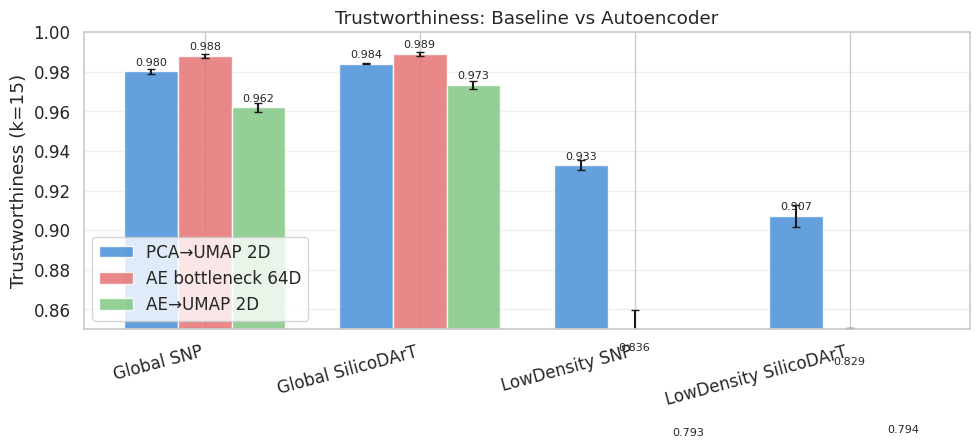

✓ Saved


In [3]:
trust_agg = trust_df.groupby("dataset").agg(
    baseline_mean=("trust_baseline_umap2d", "mean"),
    baseline_std=("trust_baseline_umap2d", "std"),
    ae_bn_mean=("trust_ae_bottleneck64", "mean"),
    ae_bn_std=("trust_ae_bottleneck64", "std"),
    ae_umap_mean=("trust_ae_umap2d", "mean"),
    ae_umap_std=("trust_ae_umap2d", "std"),
).reindex(DATASETS)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(DATASETS))
w = 0.25

bars1 = ax.bar(x - w, trust_agg["baseline_mean"], w, yerr=trust_agg["baseline_std"],
               label="PCA→UMAP 2D", color="#4A90D9", capsize=3, alpha=0.85)
bars2 = ax.bar(x, trust_agg["ae_bn_mean"], w, yerr=trust_agg["ae_bn_std"],
               label="AE bottleneck 64D", color="#E57373", capsize=3, alpha=0.85)
bars3 = ax.bar(x + w, trust_agg["ae_umap_mean"], w, yerr=trust_agg["ae_umap_std"],
               label="AE→UMAP 2D", color="#81C784", capsize=3, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([ds_labels[d] for d in DATASETS], rotation=15, ha="right")
ax.set_ylabel("Trustworthiness (k=15)")
ax.set_title("Trustworthiness: Baseline vs Autoencoder")
ax.legend(loc="lower left")
ax.set_ylim(0.85, 1.0)
ax.grid(axis="y", alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.002, f"{h:.3f}",
                ha="center", va="bottom", fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / "01_trustworthiness_comparison.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("✓ Saved")

## 2. Estabilidad kNN entre seeds

Comparamos el Jaccard de aristas y vecindarios kNN entre pares de seeds para:
- **Baseline**: grafo kNN del pipeline PCA
- **AE**: grafo kNN construido sobre bottleneck 64D

In [4]:
def compute_knn_jaccard(edges1, edges2):
    set1 = {(e["source"], e["target"]) for e in edges1}
    set2 = {(e["source"], e["target"]) for e in edges2}
    inter = len(set1 & set2)
    union = len(set1 | set2)
    return inter / union if union > 0 else 1.0

def compute_neighbor_jaccard(edges1, edges2, ids):
    def neighbors_dict(edges):
        d = {}
        for e in edges:
            d.setdefault(e["source"], set()).add(e["target"])
        return d
    n1, n2 = neighbors_dict(edges1), neighbors_dict(edges2)
    jaccards = []
    for nid in ids:
        s1, s2 = n1.get(nid, set()), n2.get(nid, set())
        u = len(s1 | s2)
        jaccards.append(len(s1 & s2) / u if u > 0 else 1.0)
    return np.mean(jaccards)

stability_results = []
seed_pairs = [(42, 52), (42, 62), (52, 62)]

for ds in DATASETS:
    print(f"\n--- {ds_labels[ds]} ---")
    ae_nodes = load_nodes(AE_TAG, ds, 42)
    ids = [n["id"] for n in ae_nodes]
    
    for s1, s2 in seed_pairs:
        b_e1, b_e2 = load_edges(BASELINE_TAG, ds, s1), load_edges(BASELINE_TAG, ds, s2)
        ae_e1, ae_e2 = load_edges(AE_TAG, ds, s1), load_edges(AE_TAG, ds, s2)
        
        stability_results.append({
            "dataset": ds, "seeds": f"{s1}-{s2}",
            "baseline_edge_jaccard": compute_knn_jaccard(b_e1, b_e2),
            "baseline_neigh_jaccard": compute_neighbor_jaccard(b_e1, b_e2, ids),
            "ae_edge_jaccard": compute_knn_jaccard(ae_e1, ae_e2),
            "ae_neigh_jaccard": compute_neighbor_jaccard(ae_e1, ae_e2, ids),
        })
        print(f"  {s1}-{s2}: baseline_J={stability_results[-1]['baseline_edge_jaccard']:.4f}  ae_J={stability_results[-1]['ae_edge_jaccard']:.4f}")

stab_df = pd.DataFrame(stability_results)
print("\n✓ Stability computed")


--- Global SNP ---
  42-52: baseline_J=0.8911  ae_J=0.5250
  42-62: baseline_J=0.8882  ae_J=0.5184
  52-62: baseline_J=0.8852  ae_J=0.5270

--- Global SilicoDArT ---
  42-52: baseline_J=0.8848  ae_J=0.5042
  42-62: baseline_J=0.8713  ae_J=0.4915
  52-62: baseline_J=0.8982  ae_J=0.4994

--- LowDensity SNP ---
  42-52: baseline_J=0.9135  ae_J=0.1545
  42-62: baseline_J=0.9031  ae_J=0.1704
  52-62: baseline_J=0.9089  ae_J=0.1642

--- LowDensity SilicoDArT ---
  42-52: baseline_J=0.9081  ae_J=0.2023
  42-62: baseline_J=0.9079  ae_J=0.2193
  52-62: baseline_J=0.9092  ae_J=0.2008

✓ Stability computed


### Fig 02 — kNN stability comparison

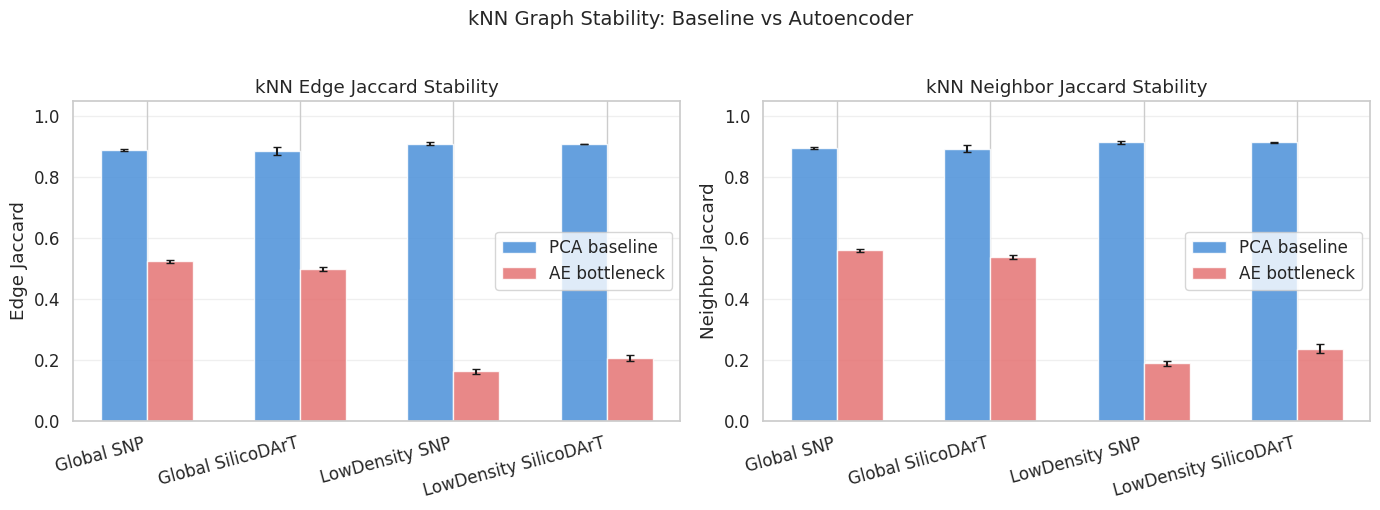

✓ Saved


In [5]:
stab_agg = stab_df.groupby("dataset").agg(
    b_edge_m=("baseline_edge_jaccard", "mean"), b_edge_s=("baseline_edge_jaccard", "std"),
    ae_edge_m=("ae_edge_jaccard", "mean"), ae_edge_s=("ae_edge_jaccard", "std"),
    b_neigh_m=("baseline_neigh_jaccard", "mean"), b_neigh_s=("baseline_neigh_jaccard", "std"),
    ae_neigh_m=("ae_neigh_jaccard", "mean"), ae_neigh_s=("ae_neigh_jaccard", "std"),
).reindex(DATASETS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(DATASETS))
w = 0.3

for i, (title, b_m, b_s, a_m, a_s) in enumerate([
    ("Edge Jaccard", "b_edge_m", "b_edge_s", "ae_edge_m", "ae_edge_s"),
    ("Neighbor Jaccard", "b_neigh_m", "b_neigh_s", "ae_neigh_m", "ae_neigh_s"),
]):
    ax = axes[i]
    ax.bar(x - w/2, stab_agg[b_m], w, yerr=stab_agg[b_s],
           label="PCA baseline", color="#4A90D9", capsize=3, alpha=0.85)
    ax.bar(x + w/2, stab_agg[a_m], w, yerr=stab_agg[a_s],
           label="AE bottleneck", color="#E57373", capsize=3, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([ds_labels[d] for d in DATASETS], rotation=15, ha="right")
    ax.set_ylabel(title)
    ax.set_title(f"kNN {title} Stability")
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("kNN Graph Stability: Baseline vs Autoencoder", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_stability_comparison.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("✓ Saved")

## 3. UMAP scatter — side by side

Baseline (PCA→UMAP) vs AE (bottleneck→UMAP), seed=42.

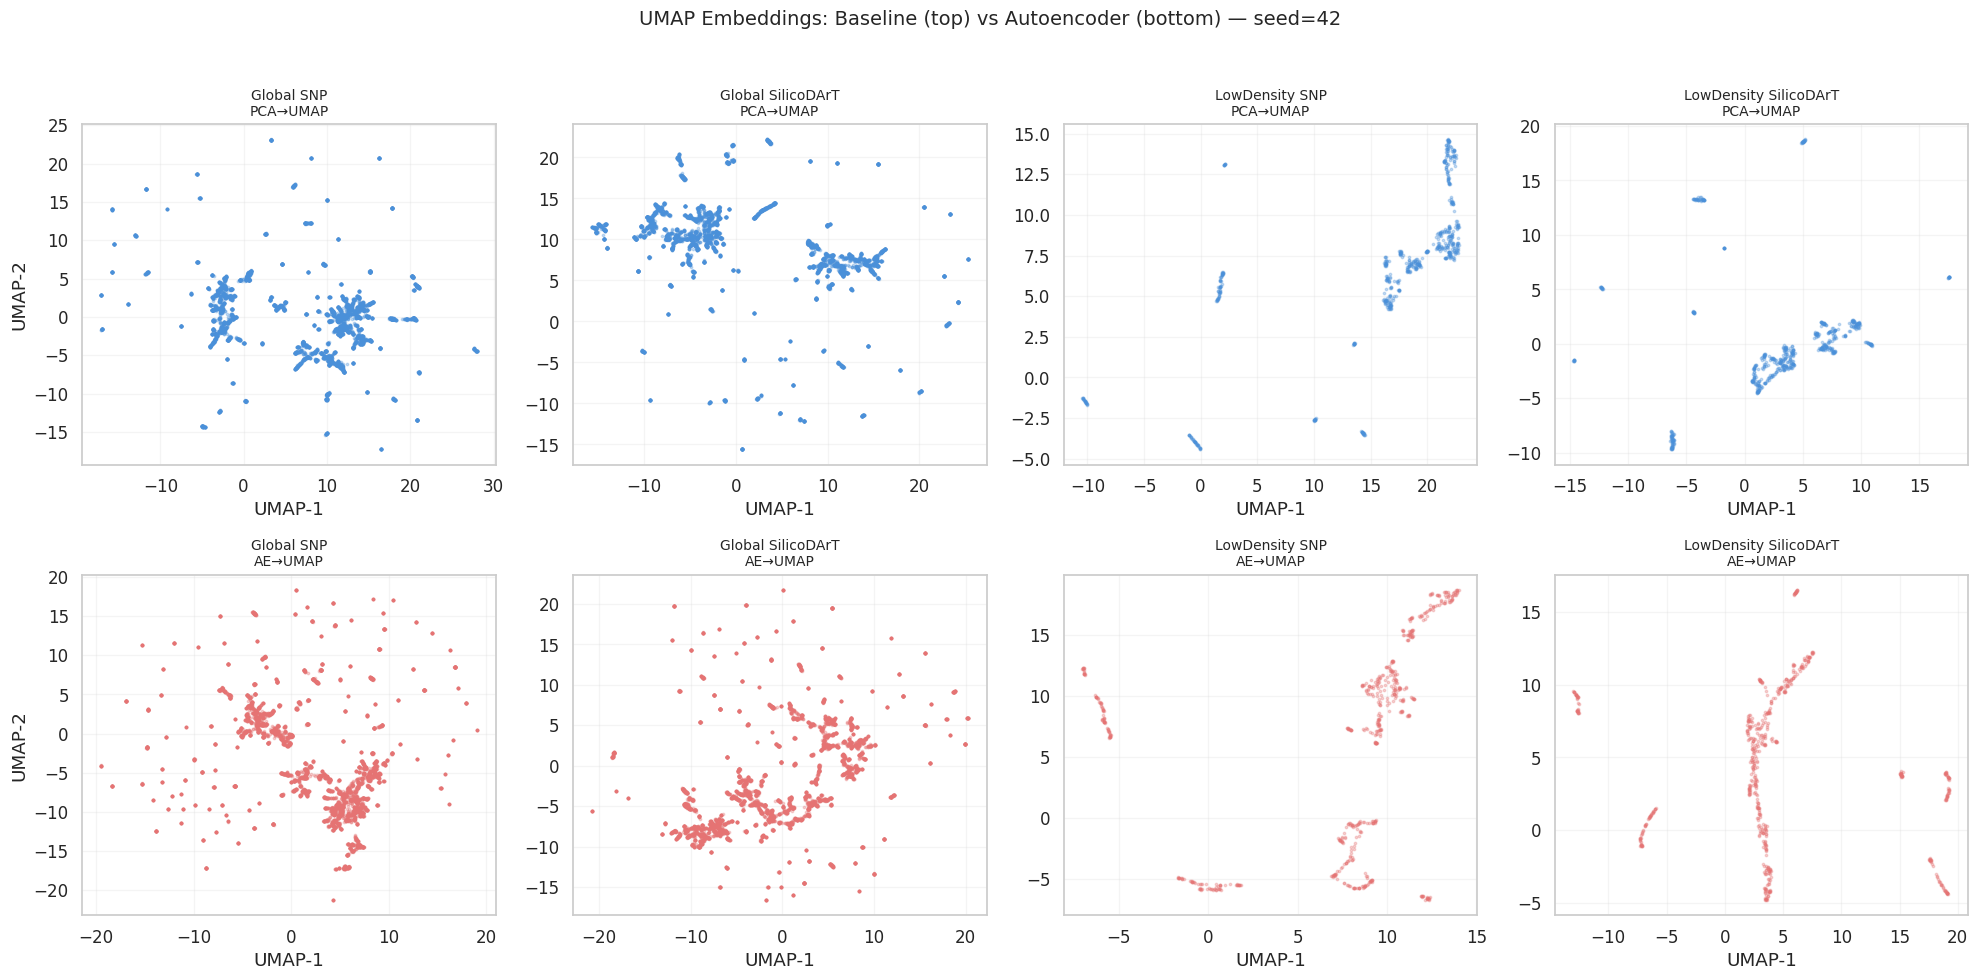

✓ Saved


In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for col, ds in enumerate(DATASETS):
    b_nodes = load_nodes(BASELINE_TAG, ds, 42)
    b_emb = np.array([n["embedding"] for n in b_nodes])
    ax = axes[0, col]
    ax.scatter(b_emb[:, 0], b_emb[:, 1], s=3, alpha=0.3, c="#4A90D9")
    ax.set_title(f"{ds_labels[ds]}\nPCA→UMAP", fontsize=10)
    ax.set_xlabel("UMAP-1")
    if col == 0: ax.set_ylabel("UMAP-2")
    ax.grid(alpha=0.2)

    ae_nodes = load_nodes(AE_TAG, ds, 42)
    ae_emb = np.array([n["embedding"] for n in ae_nodes])
    ax = axes[1, col]
    ax.scatter(ae_emb[:, 0], ae_emb[:, 1], s=3, alpha=0.3, c="#E57373")
    ax.set_title(f"{ds_labels[ds]}\nAE→UMAP", fontsize=10)
    ax.set_xlabel("UMAP-1")
    if col == 0: ax.set_ylabel("UMAP-2")
    ax.grid(alpha=0.2)

fig.suptitle("UMAP Embeddings: Baseline (top) vs Autoencoder (bottom) — seed=42", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / "03_umap_side_by_side.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("✓ Saved")

## 4. Distribución de distancias kNN

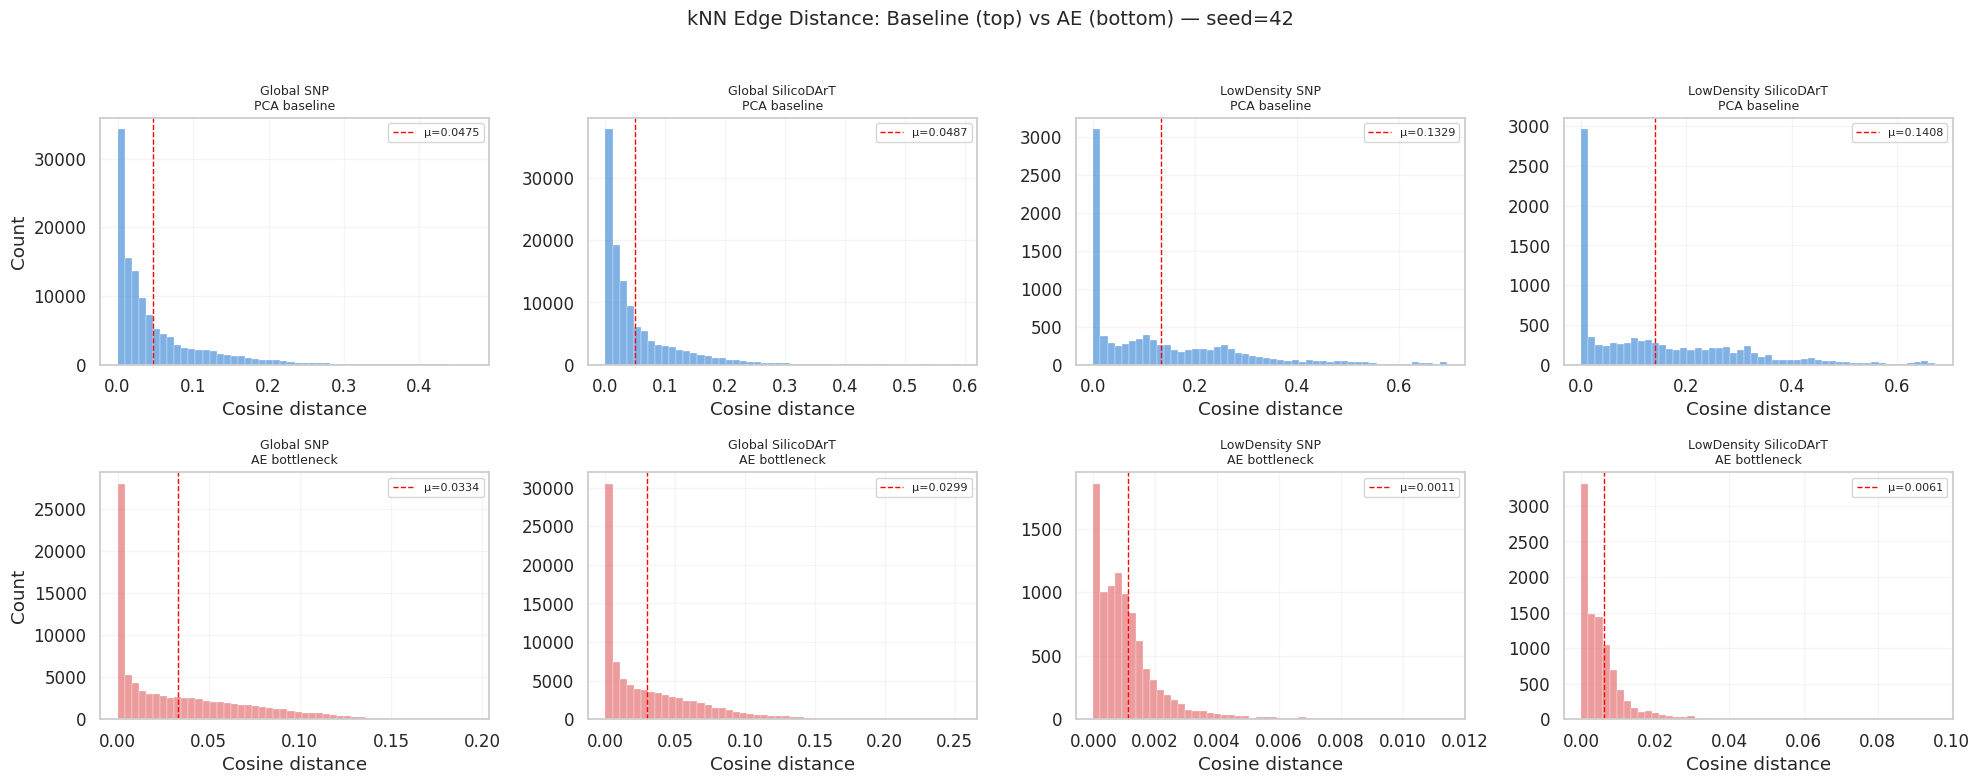

✓ Saved


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for col, ds in enumerate(DATASETS):
    for row, (tag, color, label) in enumerate([
        (BASELINE_TAG, "#4A90D9", "PCA baseline"),
        (AE_TAG, "#E57373", "AE bottleneck"),
    ]):
        edges = load_edges(tag, ds, 42)
        dists = [e["distance"] for e in edges]
        ax = axes[row, col]
        ax.hist(dists, bins=50, color=color, alpha=0.7, edgecolor="white", linewidth=0.3)
        ax.axvline(np.mean(dists), color="red", ls="--", lw=1, label=f"μ={np.mean(dists):.4f}")
        ax.set_title(f"{ds_labels[ds]}\n{label}", fontsize=9)
        ax.legend(fontsize=8)
        if col == 0: ax.set_ylabel("Count")
        ax.set_xlabel("Cosine distance")
        ax.grid(alpha=0.2)

fig.suptitle("kNN Edge Distance: Baseline (top) vs AE (bottom) — seed=42", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / "04_distance_comparison.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("✓ Saved")

## 5. AE Training Curves

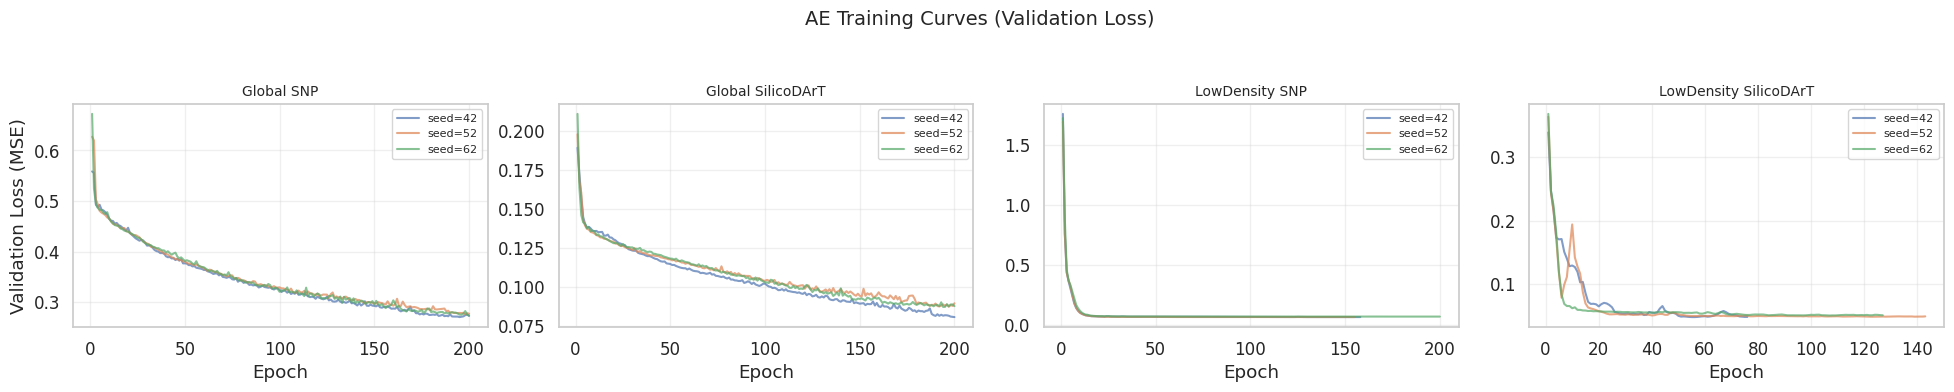

✓ Saved


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for col, ds in enumerate(DATASETS):
    ax = axes[col]
    for seed in SEEDS:
        hp = ROOT / "experiments" / ds / AE_TAG / f"seed{seed}" / "training_history.json"
        with open(hp) as f:
            hist = json.load(f)
        ep = range(1, len(hist["val_loss"]) + 1)
        ax.plot(ep, hist["val_loss"], alpha=0.7, label=f"seed={seed}")
    ax.set_title(ds_labels[ds], fontsize=10)
    ax.set_xlabel("Epoch")
    if col == 0: ax.set_ylabel("Validation Loss (MSE)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle("AE Training Curves (Validation Loss)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIG_DIR / "05_ae_training_curves.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("✓ Saved")

## 6. Summary Table

In [9]:
rows = []
for ds in DATASETS:
    val = load_validation(ds)
    b_t_m = val["trustworthiness"]["mean"]
    b_t_s = val["trustworthiness"]["std"]
    
    ae_t = trust_df[trust_df["dataset"] == ds]
    ae_bn_m = ae_t["trust_ae_bottleneck64"].mean()
    ae_bn_s = ae_t["trust_ae_bottleneck64"].std()
    ae_2d_m = ae_t["trust_ae_umap2d"].mean()
    
    stab = stab_df[stab_df["dataset"] == ds]
    b_stab = stab["baseline_edge_jaccard"].mean()
    ae_stab = stab["ae_edge_jaccard"].mean()
    
    vl = []
    for seed in SEEDS:
        sp = ROOT / "experiments" / ds / AE_TAG / f"seed{seed}" / "ae_embedding_stats.json"
        with open(sp) as f: s = json.load(f)
        vl.append(s["best_val_loss"])
    
    rows.append({
        "Dataset": ds_labels[ds],
        "Trust (PCA 2D)": f"{b_t_m:.4f}±{b_t_s:.4f}",
        "Trust (AE 64D)": f"{ae_bn_m:.4f}±{ae_bn_s:.4f}",
        "Trust (AE 2D)": f"{ae_2d_m:.4f}",
        "Δ Trust": f"{ae_bn_m - b_t_m:+.4f}",
        "Stab PCA": f"{b_stab:.4f}",
        "Stab AE": f"{ae_stab:.4f}",
        "AE val loss": f"{np.mean(vl):.4f}±{np.std(vl):.4f}",
    })

summary_df = pd.DataFrame(rows)
summary_df.style.set_caption("Baseline (PCA→UMAP) vs Autoencoder (Level 1) — Comparison")

,Dataset,Trust (PCA 2D),Trust (AE 64D),Trust (AE 2D),Δ Trust,Stab PCA,Stab AE,AE val loss
0,Global SNP,0.9756±0.0017,0.9879±0.0011,0.9621,+0.0123,0.8882,0.5235,0.2737±0.0023
1,Global SilicoDArT,0.9792±0.0006,0.9889±0.0009,0.9733,+0.0097,0.8848,0.4983,0.0850±0.0031
2,LowDensity SNP,0.9334±0.0018,0.8360±0.0236,0.7931,-0.0974,0.9085,0.1630,0.0669±0.0019
3,LowDensity SilicoDArT,0.9105±0.0046,0.8288±0.0218,0.7945,-0.0817,0.9084,0.2075,0.0494±0.0010
